In [1]:
import sys
import numpy as np
import pandas as pd
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
from sksurv.util import Surv
import os
import joblib

from sksurv.metrics import concordance_index_censored, cumulative_dynamic_auc, integrated_brier_score, brier_score
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import StratifiedKFold

import shap

In [2]:
# SELECTION OF NEEDED PARAMETERS
# THE ONLY OTHER BOX TO BE MODIFIED IS THE LIST OF FEATURES TO BE USED IN THE MODEL

# Indicate the outcome of interest ['OS','PSF']
outcome = 'PFS'
status = f'STATUS {outcome}'

# Set this to True if you want to save figures/data, and False otherwise
save_output = True

In [3]:
# Load data
X_train = pd.read_excel("Data/X_train.xlsx").iloc[:, 1:]
X_test  = pd.read_excel("Data/X_test.xlsx").iloc[:, 1:]
X_extval = pd.read_excel("Data/X_extval.xlsx").iloc[:, 1:]

y_train_df = pd.read_excel("Data/y_train.xlsx").iloc[:, 1:]
y_test_df  = pd.read_excel("Data/y_test.xlsx").iloc[:, 1:]
y_extval_df = pd.read_excel("Data/y_extval.xlsx").iloc[:, 1:]

y_train_df = y_train_df.rename(columns={status: "event", outcome: "time"})
y_test_df = y_test_df.rename(columns={status: "event", outcome: "time"})
y_extval_df = y_extval_df.rename(columns={status: "event", outcome: "time"})

y_tr = Surv.from_dataframe("event", "time", y_train_df)
y_te  = Surv.from_dataframe("event", "time", y_test_df)
y_ev = Surv.from_dataframe("event", "time", y_extval_df)

In [4]:
def cindex(y_true, y_pred):
    return concordance_index_censored(
        y_true["event"], y_true["time"], y_pred
    )[0]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=31)

def stratify_labels(y):
    return y["event"].astype(int)

class SurvivalUnivariateSelector(BaseEstimator, TransformerMixin):
    def __init__(self, model, threshold=0.55, cv=3):
        self.model = model
        self.threshold = threshold
        self.cv = cv

    def fit(self, X, y):
        Xc = X.copy()
        self.selected_features_ = []

        skf = StratifiedKFold(n_splits=self.cv, shuffle=True, random_state=42)
        strat_labels = stratify_labels(y)

        for col in Xc.columns:
            scores = []

            for train_idx, val_idx in skf.split(Xc, strat_labels):
                X_tr, X_val = Xc.iloc[train_idx][[col]], Xc.iloc[val_idx][[col]]
                y_tr, y_val = y[train_idx], y[val_idx]

                model = clone(self.model)
                model.fit(X_tr, y_tr)
                preds = model.predict(X_val)

                scores.append(cindex(y_val, preds))

            if np.mean(scores) > self.threshold:
                self.selected_features_.append(col)

        if len(self.selected_features_) == 0:
            self.selected_features_ = list(Xc.columns)

        return self

    def transform(self, X):
        Xc = X.copy()
        return Xc[self.selected_features_]

# SSVM_univ

In [5]:
# Indicate the model to be used
file = "SSVM_univ.joblib"

## Survival analysis

In [6]:
model_fs = file.replace(".joblib", "")
name, fs = model_fs.rsplit("_", 1)

# Load pipeline
pipeline = joblib.load(os.path.join("Results", file))

fs_step = pipeline.named_steps.get("fs", None)
m = pipeline.named_steps.get("model", None)

features_model = m.feature_names_in_
if fs=="univ":
    X_tr = X_train[features_model]
    X_t = X_test[features_model]
    X_ev = X_extval[features_model]
else:
    X_tr = X_train
    X_t = X_test
    X_ev = X_extval

In [7]:
# Arrays of risk scores predicted by the model

y_pred_train = m.predict(X_tr)
y_pred_test = m.predict(X_t)
y_pred_extval = m.predict(X_ev)

In [8]:
# Evaluation C-index
cindex_ev = cindex(y_ev, y_pred_extval)
print(f"External validation C-index ({model_fs}): {cindex_ev:.4f}")

External validation C-index (SSVM_univ): 0.6300


In [9]:
# Time points for time-dependent metrics

times_obs = y_ev["time"]
N = len(times_obs)
min_at_risk = int(np.ceil(0.10 * N))  # 10% threshold
candidate_times = np.sort(np.unique(times_obs))
# number at risk at each time
n_at_risk = np.array([
    np.sum(times_obs >= t)
    for t in candidate_times
])
valid_times = candidate_times[n_at_risk >= min_at_risk]
t_max = valid_times.max()
n_time_points = 20
times = np.linspace(candidate_times.min(), t_max, n_time_points)

Text(0.95, 0.95, 'mean AUC: 0.685')

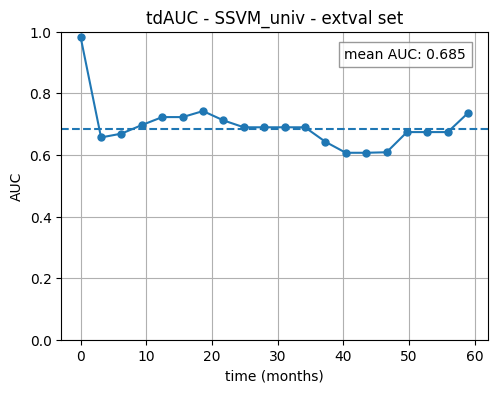

In [10]:
# tdAUC
time_auc_extval, mean_auc_extval = cumulative_dynamic_auc(y_tr, y_ev, y_pred_extval, times)

plt.figure(figsize=(5.5,4))
plt.plot(times, time_auc_extval, marker="o", markersize=5)
plt.axhline(mean_auc_extval, linestyle="--")
plt.title(f"tdAUC - {model_fs} - extval set")
plt.xlabel("time (months)")
plt.ylabel("AUC")
plt.ylim([0, 1])
plt.grid(True)
plt.text(x=0.95, y=0.95, s=f"mean AUC: {mean_auc_extval:.3f}", 
        va='top', ha='right', transform=plt.gca().transAxes, 
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='grey'))

# Save plots
#plt.savefig(f"Extval/AUC_{name}.png")

In [11]:
# tdBS
surv_funct_extval = m.predict_survival_function(X_ev)
sf_extval = np.asarray([[fn(t) for t in times] for fn in surv_funct_extval])
_, time_brier_extval = brier_score(y_tr, y_ev, sf_extval, times)
integ_brier_extval = integrated_brier_score(y_tr, y_ev, sf_extval, times)

plt.figure(figsize=(5.5,4))
plt.plot(times, time_brier_extval, marker="o", markersize=5)
plt.axhline(integ_brier_extval, linestyle="--")
plt.title(f"tdBS - {model_fs} - extval set")
plt.xlabel("time (months from infusion)")
plt.ylabel("Brier score")
plt.ylim([0, 0.5])
plt.grid(True)
plt.text(x=0.05, y=0.95, s=f"integrated Brier score: {integ_brier_extval:.3f}", 
        va='top', ha='left', transform=plt.gca().transAxes, 
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='grey'))

# Save plots
#plt.savefig(f"Extval/BS_{name}.png")

AttributeError: 'FastKernelSurvivalSVM' object has no attribute 'predict_survival_function'

## Explainability

In [12]:
# Load dataset for explainability
X_extval_expl = pd.read_excel('Data/X_extval_expl.xlsx')

# Load explainer
explainer = pickle.load(open(f'Explainability/{model_fs}/explainer.pkl', 'rb'))

In [13]:
# Compute shap values for external validation set
shap_values = explainer(X_ev)

# Link shap values to original data
features_original = np.array([n.removeprefix('log_') for n in features_model])
X_extval_expl = X_extval_expl.loc[:,features_original]
for i, c in enumerate(features_original):
    shap_values.feature_names[i] = c
shap_values.data = X_extval_expl.values

# Save shap values
if save_output:
    with open(f'Extval/shap_values_{model_fs}_extval.pkl', 'wb') as f:
        pickle.dump(shap_values, f)

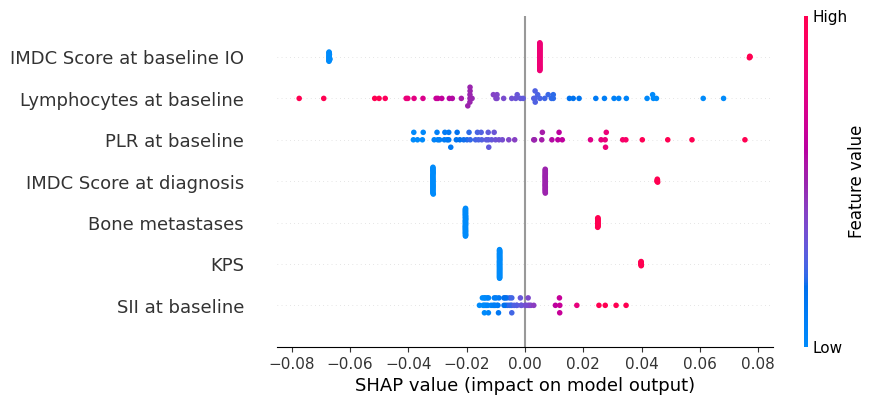

In [14]:
# Plot the SHAP values for all the selected features

plt.figure(figsize=(30, 10))
shap.plots.beeswarm(shap_values, max_display=X_ev.shape[1], show=False)

if save_output:
    plt.savefig(f'Extval/Beeswarm_{model_fs}_complete.png', format='png', dpi=300, bbox_inches='tight')

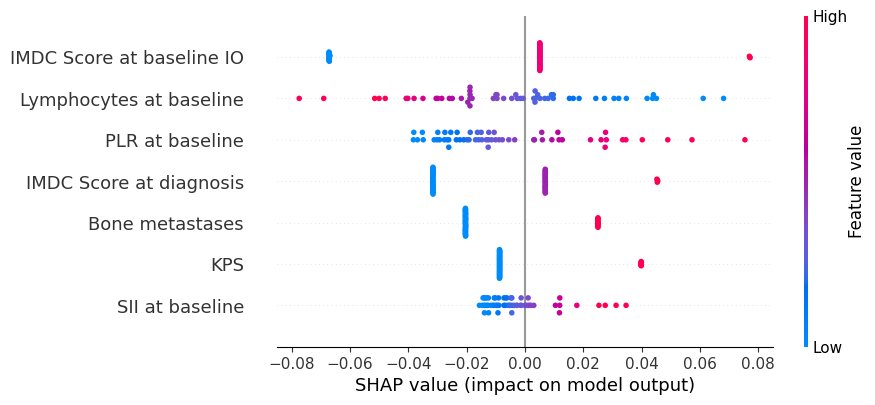

In [15]:
# Plot the SHAP values for all the selected features

plt.figure(figsize=(30, 10))
shap.plots.beeswarm(shap_values, max_display=7, show=False)

if save_output:
    plt.savefig(f'Extval/Beeswarm_{model_fs}_reduced.png', format='png', dpi=300, bbox_inches='tight')

# EST_none

In [16]:
# Indicate the model to be used
file = "EST_none.joblib"

## Survival analysis

In [17]:
model_fs = file.replace(".joblib", "")
name, fs = model_fs.rsplit("_", 1)

# Load pipeline
pipeline = joblib.load(os.path.join("Results", file))

fs_step = pipeline.named_steps.get("fs", None)
m = pipeline.named_steps.get("model", None)

features_model = m.feature_names_in_
if fs=="univ":
    X_tr = X_train[features_model]
    X_t = X_test[features_model]
    X_ev = X_extval[features_model]
else:
    X_tr = X_train
    X_t = X_test
    X_ev = X_extval

In [18]:
# Arrays of risk scores predicted by the model

y_pred_train = m.predict(X_tr)
y_pred_test = m.predict(X_t)
y_pred_extval = m.predict(X_ev)

In [19]:
# Evaluation C-index
cindex_ev = cindex(y_ev, y_pred_extval)
print(f"External validation C-index ({model_fs}): {cindex_ev:.4f}")

External validation C-index (EST_none): 0.6116


In [20]:
# Time points for time-dependent metrics

times_obs = y_ev["time"]
N = len(times_obs)
min_at_risk = int(np.ceil(0.10 * N))  # 10% threshold
candidate_times = np.sort(np.unique(times_obs))
# number at risk at each time
n_at_risk = np.array([
    np.sum(times_obs >= t)
    for t in candidate_times
])
valid_times = candidate_times[n_at_risk >= min_at_risk]
t_max = valid_times.max()
n_time_points = 20
times = np.linspace(candidate_times.min(), t_max, n_time_points)

Text(0.95, 0.95, 'mean AUC: 0.660')

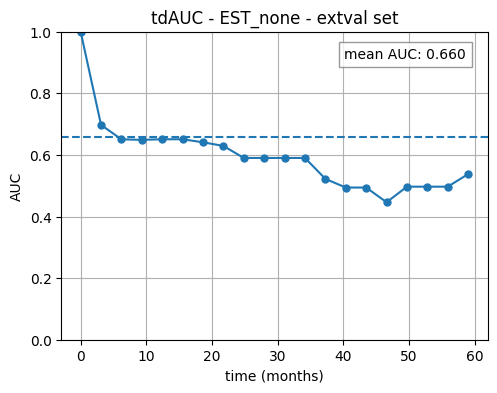

In [21]:
# tdAUC
time_auc_extval, mean_auc_extval = cumulative_dynamic_auc(y_tr, y_ev, y_pred_extval, times)

plt.figure(figsize=(5.5,4))
plt.plot(times, time_auc_extval, marker="o", markersize=5)
plt.axhline(mean_auc_extval, linestyle="--")
plt.title(f"tdAUC - {model_fs} - extval set")
plt.xlabel("time (months)")
plt.ylabel("AUC")
plt.ylim([0, 1])
plt.grid(True)
plt.text(x=0.95, y=0.95, s=f"mean AUC: {mean_auc_extval:.3f}", 
        va='top', ha='right', transform=plt.gca().transAxes, 
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='grey'))

# Save plots
#plt.savefig(f"Extval/AUC_{name}.png")

Text(0.05, 0.95, 'integrated Brier score: 0.184')

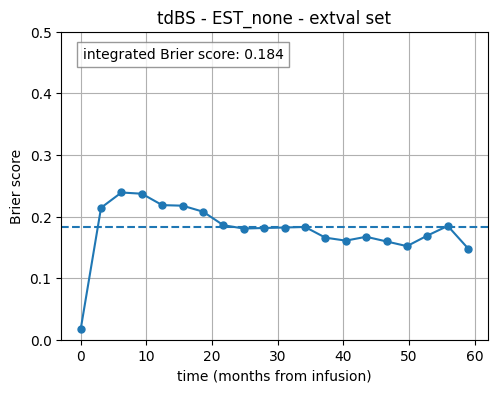

In [22]:
# tdBS
surv_funct_extval = m.predict_survival_function(X_ev)
sf_extval = np.asarray([[fn(t) for t in times] for fn in surv_funct_extval])
_, time_brier_extval = brier_score(y_tr, y_ev, sf_extval, times)
integ_brier_extval = integrated_brier_score(y_tr, y_ev, sf_extval, times)

plt.figure(figsize=(5.5,4))
plt.plot(times, time_brier_extval, marker="o", markersize=5)
plt.axhline(integ_brier_extval, linestyle="--")
plt.title(f"tdBS - {model_fs} - extval set")
plt.xlabel("time (months from infusion)")
plt.ylabel("Brier score")
plt.ylim([0, 0.5])
plt.grid(True)
plt.text(x=0.05, y=0.95, s=f"integrated Brier score: {integ_brier_extval:.3f}", 
        va='top', ha='left', transform=plt.gca().transAxes, 
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='grey'))

# Save plots
#plt.savefig(f"Extval/BS_{name}.png")

## Explainability

In [23]:
# Load dataset for explainability
X_extval_expl = pd.read_excel('Data/X_extval_expl.xlsx')

# Load explainer
explainer = pickle.load(open(f'Explainability/{model_fs}/explainer.pkl', 'rb'))

In [24]:
# Compute shap values for external validation set
shap_values = explainer(X_ev)

# Link shap values to original data
features_original = np.array([n.removeprefix('log_') for n in features_model])
X_extval_expl = X_extval_expl.loc[:,features_original]
for i, c in enumerate(features_original):
    shap_values.feature_names[i] = c
shap_values.data = X_extval_expl.values

# Save shap values
if save_output:
    with open(f'Extval/shap_values_{model_fs}_extval.pkl', 'wb') as f:
        pickle.dump(shap_values, f)

PermutationExplainer explainer: 58it [02:30,  2.84s/it]                        


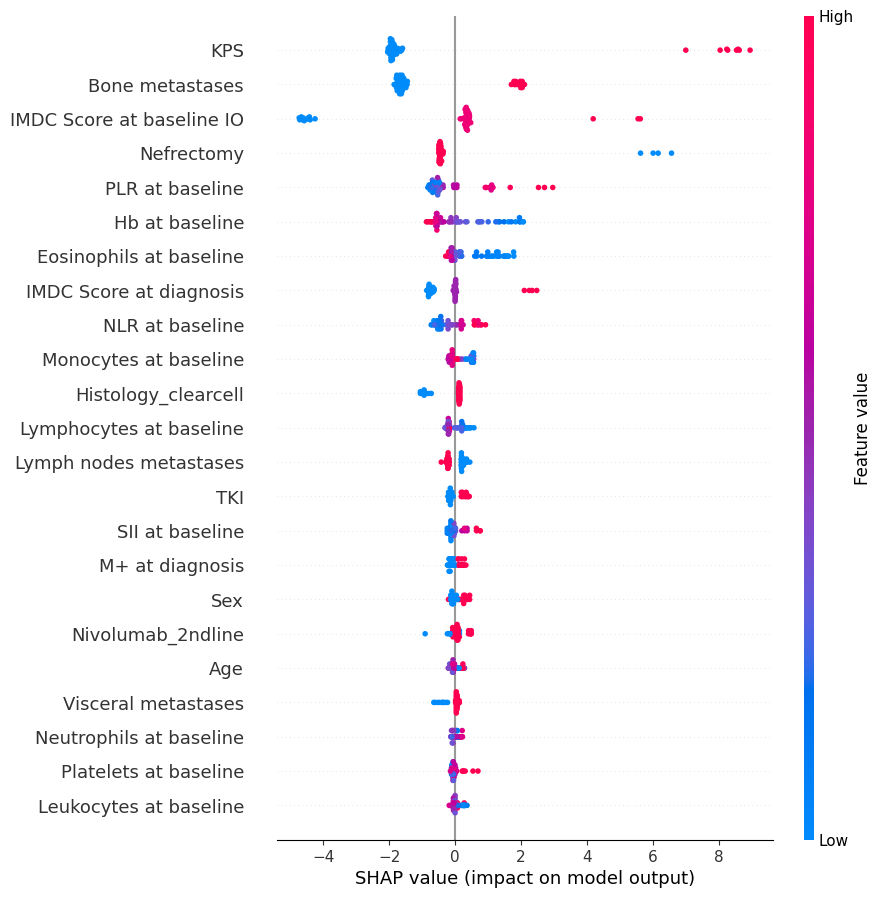

In [25]:
# Plot the SHAP values for all the selected features

plt.figure(figsize=(30, 10))
shap.plots.beeswarm(shap_values, max_display=X_ev.shape[1], show=False)

if save_output:
    plt.savefig(f'Extval/Beeswarm_{model_fs}_complete.png', format='png', dpi=300, bbox_inches='tight')

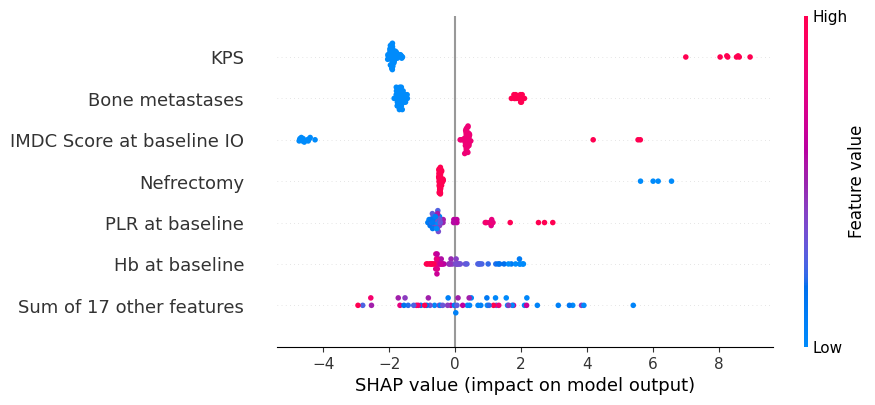

In [26]:
# Plot the SHAP values for all the selected features

plt.figure(figsize=(30, 10))
shap.plots.beeswarm(shap_values, max_display=7, show=False)

if save_output:
    plt.savefig(f'Extval/Beeswarm_{model_fs}_reduced.png', format='png', dpi=300, bbox_inches='tight')